#Clustering Jerárquico y SVD para la creación de perfiles socioeconómicos por entidad
Dataset: ENIGH 2022 Unidad de análisis: entidad federativa

## 0. Instalación y configuración

In [1]:
!pip install -q geopandas mapclassify

In [2]:
#Instalamos las librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings, gc, time, itertools, io, requests
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform

SEED = 42
np.random.seed(SEED)

## 1. Carga de ENIGH 2022 y construcción de la matriz entidad × perfil

In [3]:
URL_ENIGH = ('https://www.inegi.org.mx/contenidos/programas/enigh/nc/2022/'
             'microdatos/enigh2022_ns_concentradohogar_csv.zip')
#Usamos dos metodos para la carga en caso de que uno falle
try:
    df_raw = pd.read_csv(URL_ENIGH, compression='zip', encoding='latin1', low_memory=False)
    print(f'Descarga exitosa: {df_raw.shape}')
except Exception as e:
    r = requests.get(URL_ENIGH, timeout=120)
    df_raw = pd.read_csv(io.BytesIO(r.content), compression='zip',
                          encoding='latin1', low_memory=False)
    print(f'Descarga alternativa: {df_raw.shape}')

Descarga exitosa: (90102, 126)


In [4]:
FEATURES_AGG = ['ing_cor','gasto_mon','gsalud','gtransporte',
                 'educa_jefe','tot_integ','percep_ing']

# Filtrar solo columnas existentes
feats_ok = [f for f in FEATURES_AGG if f in df_raw.columns]
print('Features disponibles:', feats_ok)

# Construir entidad
df_raw['entidad'] = df_raw['ubica_geo'].astype(str).str.zfill(5).str[:2].astype(int)

# Agregación por mediana
X = (df_raw.groupby('entidad')[feats_ok]
           .median()
           .dropna())

X

Features disponibles: ['ing_cor', 'gasto_mon', 'educa_jefe', 'tot_integ', 'percep_ing']


,ing_cor,gasto_mon,educa_jefe,tot_integ,percep_ing
entidad,,,,,
1,54286.000,33593.840,6.0,4.0,2.0
2,62690.150,37140.400,6.0,3.0,2.0
3,66968.510,36631.970,6.0,3.0,2.0
4,41853.950,28546.710,6.0,3.0,2.0
5,54137.060,32495.200,6.0,3.0,2.0
6,50362.420,31865.600,6.0,3.0,2.0
7,28469.605,20801.550,4.0,4.0,2.0
8,51688.500,26900.470,6.0,3.0,2.0
9,57196.710,36971.350,6.0,3.0,2.0


In [5]:
# Estandarizar para clustering
scaler = StandardScaler()
X_std  = scaler.fit_transform(X)
X_std_df = pd.DataFrame(X_std, index=X.index, columns=feats_ok)

# Nombres de entidades
ENTIDADES = {
    1:'Aguascalientes', 2:'Baja California', 3:'Baja California Sur',
    4:'Campeche', 5:'Coahuila', 6:'Colima', 7:'Chiapas', 8:'Chihuahua',
    9:'CDMX', 10:'Durango', 11:'Guanajuato', 12:'Guerrero', 13:'Hidalgo',
    14:'Jalisco', 15:'Estado de México', 16:'Michoacán', 17:'Morelos',
    18:'Nayarit', 19:'Nuevo León', 20:'Oaxaca', 21:'Puebla', 22:'Querétaro',
    23:'Quintana Roo', 24:'San Luis Potosí', 25:'Sinaloa', 26:'Sonora',
    27:'Tabasco', 28:'Tamaulipas', 29:'Tlaxcala', 30:'Veracruz',
    31:'Yucatán', 32:'Zacatecas'
}
X.index = X.index.map(lambda e: ENTIDADES.get(e, str(e)))
X_std_df.index = X.index
print('Índice asignado:', X.index.tolist()[:5])

Índice asignado: ['Aguascalientes', 'Baja California', 'Baja California Sur', 'Campeche', 'Coahuila']


## 2. Parte A
# Clustering Jerárquico de Entidades

### Teoría: Criterio de Ward y su garantía de clusters compactos

El criterio de Ward une los clusters $A$ y $B$ que minimizan el incremento de varianza intra-cluster:

$$\Delta(A,B) = \frac{n_A n_B}{n_A + n_B}\|\mu_A - \mu_B\|^2$$

**Demostración:** Al unir $A$ y $B$ en $A\cup B$, el nuevo centroide es $\mu_{A\cup B} = \frac{n_A\mu_A + n_B\mu_B}{n_A+n_B}$. El incremento de inercia es:

$$W(A\cup B) - W(A) - W(B) = \sum_{i\in A}\|x_i - \mu_{A\cup B}\|^2 + \sum_{j\in B}\|x_j - \mu_{A\cup B}\|^2 - W(A) - W(B)$$

Expandiendo y simplificando (usando que $\sum_{i\in A}(x_i - \mu_A) = 0$):

$$= \frac{n_A n_B}{n_A+n_B}\|\mu_A-\mu_B\|^2$$

Ward más la euclidiana es el único enlace que garantiza clusters convexos y compactos porque penaliza directamente el incremento de varianza intra-cluster, equivalente a minimizar la suma de cuadrados total. Otros enlaces no tienen esta propiedad geométrica y pueden producir clusters elongados o con forma irregular.

### 2.1 Dendrogramas todas las combinaciones enlace × distancia

In [6]:
ENLACES   = ['ward', 'complete', 'average', 'single']
DISTANCIAS = {'euclidean': 'euclidean', 'cosine': 'cosine', 'correlation': 'correlation'}

# ward sólo funciona con euclidean el resto acepta todas
combos_validos = []
for enlace in ENLACES:
    for dist_name, dist_key in DISTANCIAS.items():
        if enlace == 'ward' and dist_key != 'euclidean':
            continue  # scipy no admite ward+no-euclidean
        combos_validos.append((enlace, dist_name, dist_key))

print(f'Combinaciones válidas: {len(combos_validos)}')
for c in combos_validos:
    print(f'  {c[0]} + {c[1]}')

Combinaciones válidas: 10
  ward + euclidean
  complete + euclidean
  complete + cosine
  complete + correlation
  average + euclidean
  average + cosine
  average + correlation
  single + euclidean
  single + cosine
  single + correlation


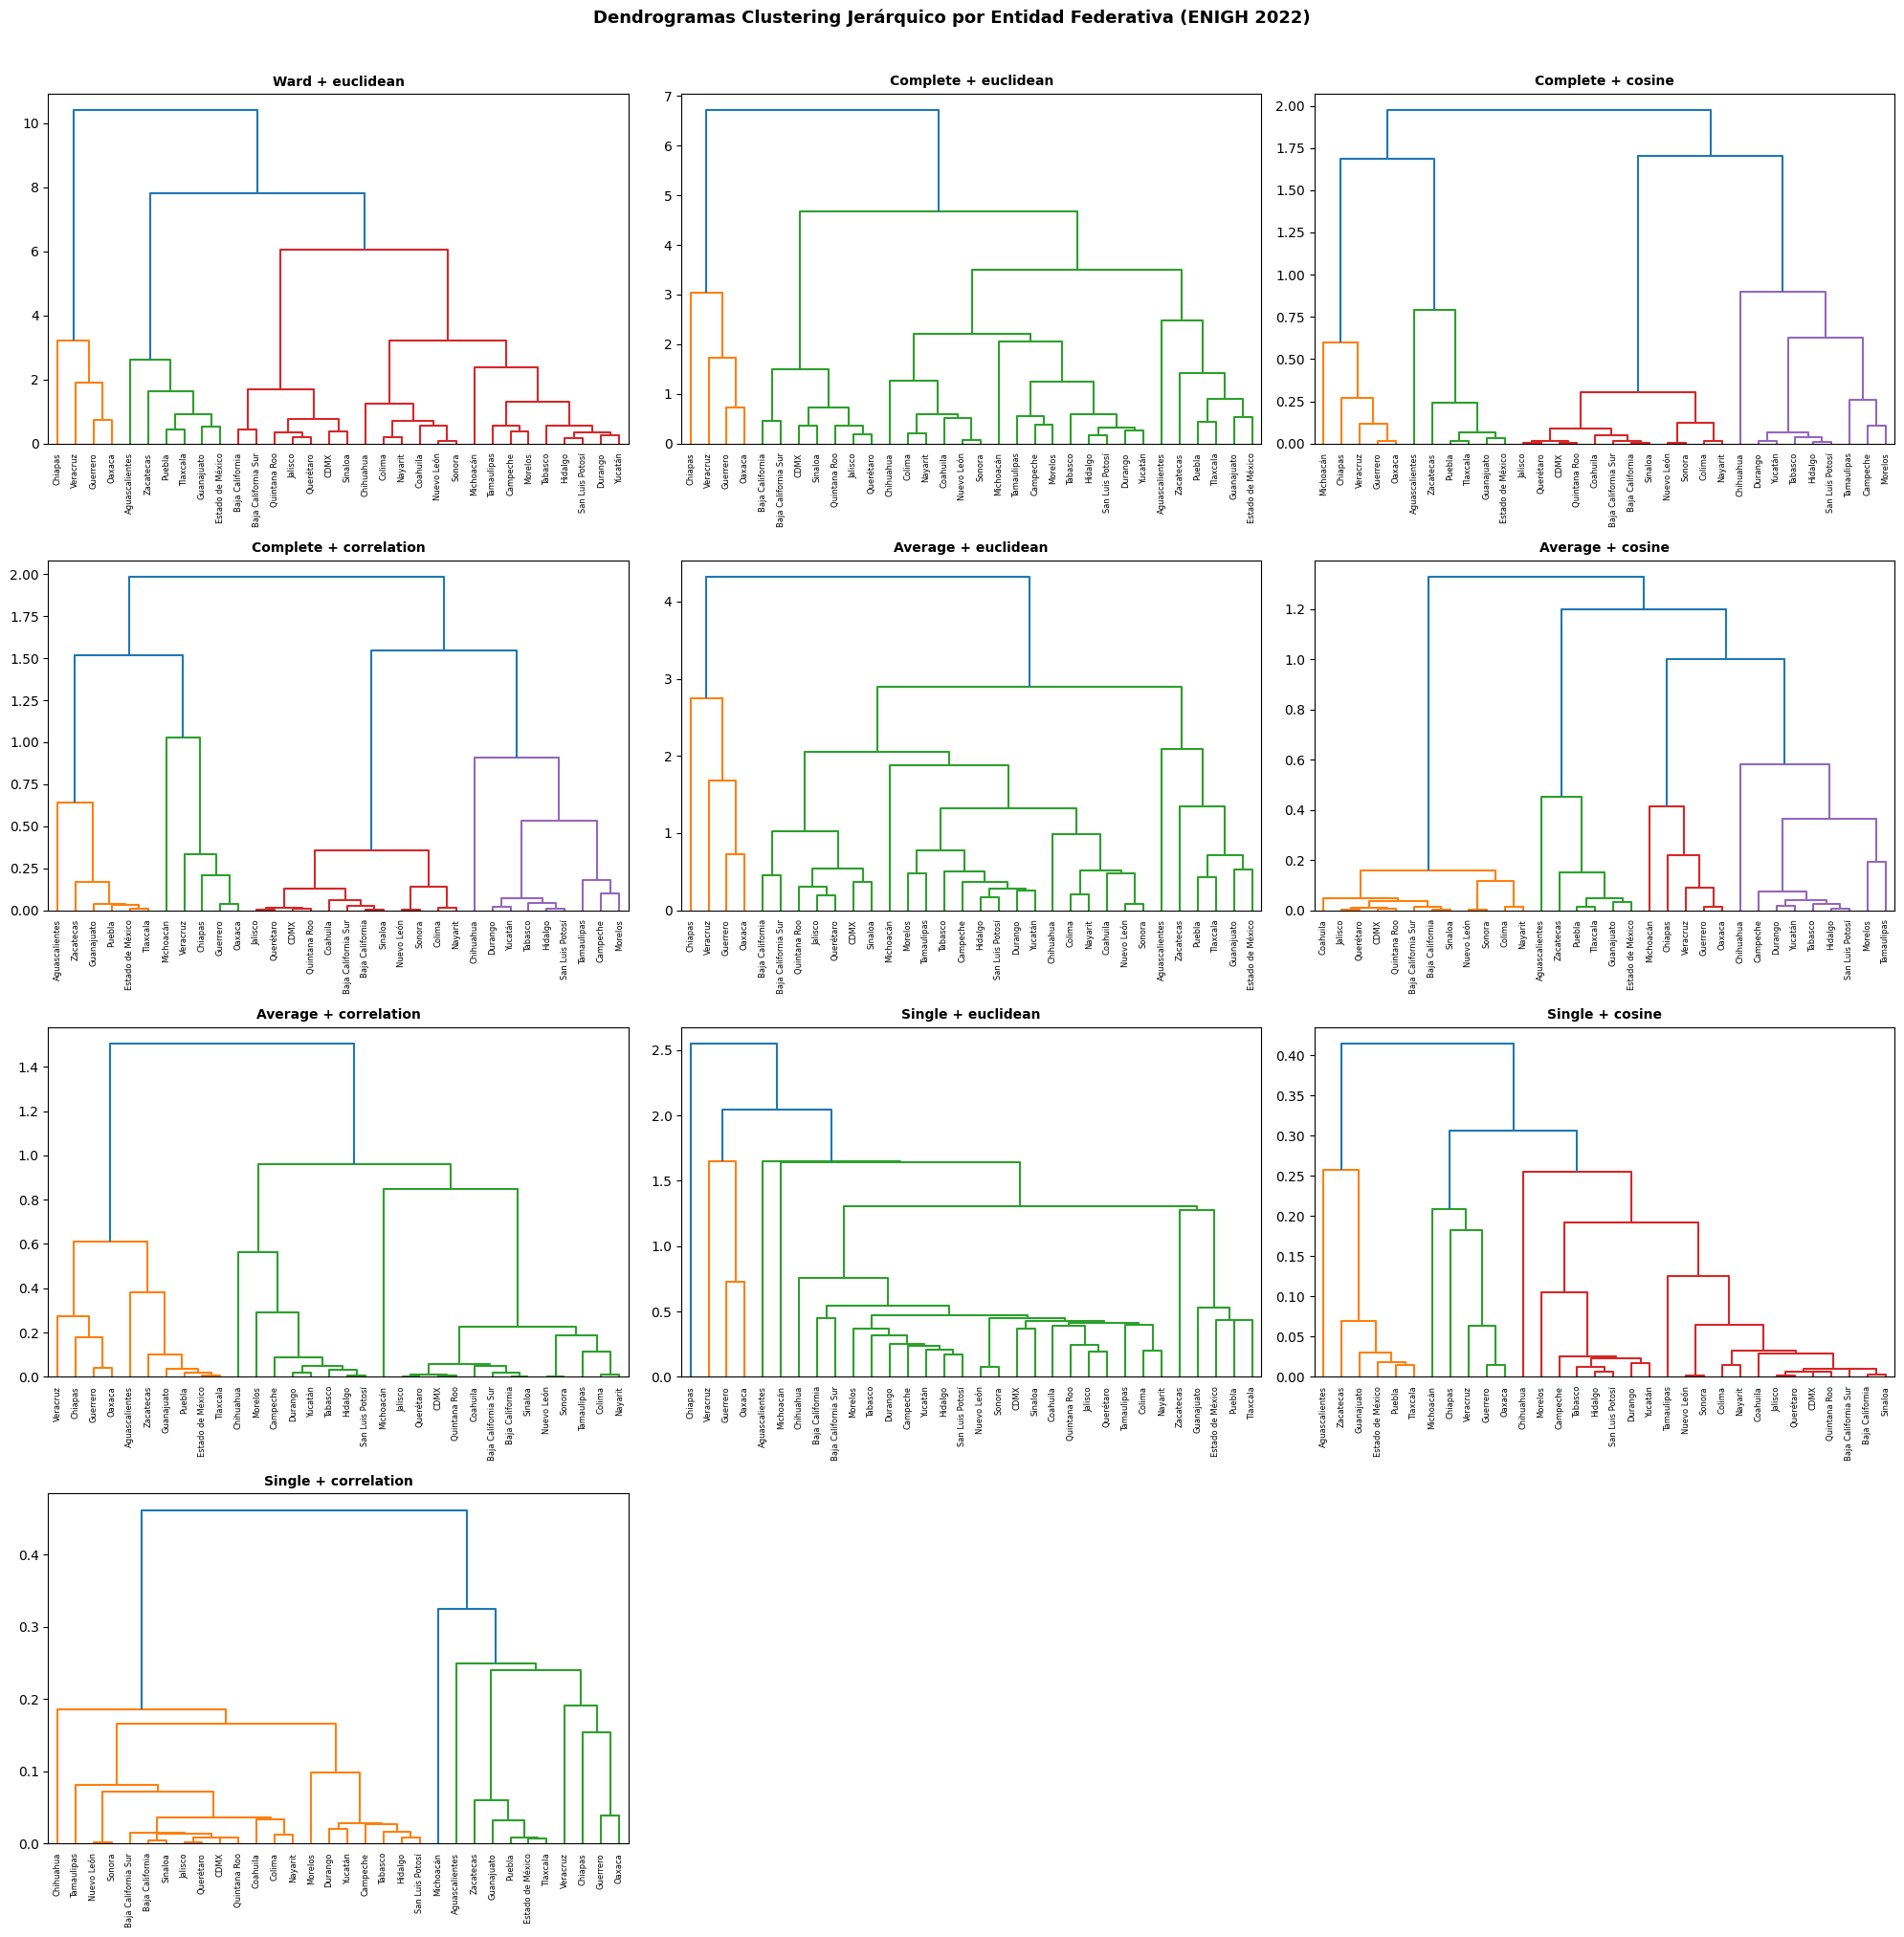

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()
link_matrices = {}

for idx, (enlace, dist_name, dist_key) in enumerate(combos_validos):
    if dist_key == 'euclidean':
        Z = linkage(X_std, method=enlace, metric='euclidean')
    elif dist_key == 'cosine':
        dist_mat = pdist(X_std, metric='cosine')
        Z = linkage(dist_mat, method=enlace)
    else:  # correlation
        dist_mat = pdist(X_std, metric='correlation')
        Z = linkage(dist_mat, method=enlace)

    link_matrices[(enlace, dist_name)] = Z

    dendrogram(Z, labels=X.index.tolist(), ax=axes[idx],
               orientation='top', leaf_rotation=90, leaf_font_size=7,
               color_threshold=0.7*max(Z[:,2]))
    axes[idx].set_title(f'{enlace.capitalize()} + {dist_name}', fontweight='bold', fontsize=10)
    axes[idx].tick_params(axis='x', labelsize=6)

# Ocultar sobrantes
for ax in axes[len(combos_validos):]:
    ax.set_visible(False)

plt.suptitle('Dendrogramas Clustering Jerárquico por Entidad Federativa (ENIGH 2022)',
              fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dendrogramas.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.2 Tabla comparativa todos los métodos jerárquicos

In [8]:
K_CORTES = [3, 4, 5, 6]
resultados_jerarquico = []

# Referencia K-Means para ARI
km_ref = {}
for k in K_CORTES:
    km_ref[k] = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X_std)

for enlace, dist_name in link_matrices:
    Z = link_matrices[(enlace, dist_name)]
    for k in K_CORTES:
        labels = fcluster(Z, k, criterion='maxclust') - 1  # 0-indexed
        if len(np.unique(labels)) < 2:
            continue
        sil = silhouette_score(X_std, labels)
        ch  = calinski_harabasz_score(X_std, labels)
        ari = adjusted_rand_score(km_ref[k], labels)
        resultados_jerarquico.append({
            'Enlace': enlace, 'Distancia': dist_name, 'k': k,
            'Silhouette': round(sil, 3),
            'CH_index':   round(ch, 1),
            'ARI_vs_KMeans': round(ari, 3)
        })

hier_df = pd.DataFrame(resultados_jerarquico)
best_hier_idx = hier_df['Silhouette'].idxmax()
hier_df['Ganador'] = ''
hier_df.loc[best_hier_idx, 'Ganador'] = 'OK'

print('Tabla comparativa Clustering Jerárquico')
display(hier_df.sort_values('Silhouette', ascending=False)
        .style.highlight_max(subset='Silhouette', color='#d4edda'))

Tabla comparativa Clustering Jerárquico


,Enlace,Distancia,k,Silhouette,CH_index,ARI_vs_KMeans,Ganador
0,ward,euclidean,3,0.490000,28.300000,1.000000,OK
16,average,euclidean,3,0.490000,28.300000,1.000000,
28,single,euclidean,3,0.482000,12.500000,0.451000,
17,average,euclidean,4,0.475000,21.900000,0.501000,
32,single,cosine,3,0.472000,25.400000,0.899000,
1,ward,euclidean,4,0.469000,38.300000,0.641000,
5,complete,euclidean,4,0.469000,38.300000,0.641000,
14,complete,correlation,5,0.462000,33.500000,0.936000,
2,ward,euclidean,5,0.461000,36.600000,0.571000,
21,average,cosine,4,0.461000,33.800000,0.822000,


In [9]:
# Mejor configuración
best_hier = hier_df.loc[best_hier_idx]
print(f'Mejor: {best_hier["Enlace"]} + {best_hier["Distancia"]}, k={int(best_hier["k"])}')

best_Z  = link_matrices[(best_hier['Enlace'], best_hier['Distancia'])]
best_k  = int(best_hier['k'])
hier_labels = fcluster(best_Z, best_k, criterion='maxclust') - 1

# Perfil por cluster
X_prof = X.copy()
X_prof['cluster_hier'] = hier_labels
profile_hier = X_prof.groupby('cluster_hier')[feats_ok].median().round(1)
print('\nPerfil mediano por cluster:')
display(profile_hier)

Mejor: ward + euclidean, k=3

Perfil mediano por cluster:


,ing_cor,gasto_mon,educa_jefe,tot_integ,percep_ing
cluster_hier,,,,,
0,29638.8,21142.0,4.0,3.0,2.0
1,39111.9,27871.4,6.0,4.0,2.0
2,51025.5,30701.0,6.0,3.0,2.0


### 2.3 Mapa de México por cluster

In [10]:
import geopandas as gpd

# Descarga shapefile México desde fuente pública
MX_SHAPEFILE_URL = 'https://raw.githubusercontent.com/JuveCampos/Shapes_Resiliencia_CDMX_CIDE/master/geojsons/Division%20Politica/DivisionEstatal.geojson'

try:
    mex = gpd.read_file(MX_SHAPEFILE_URL)
    print('GeoJSON:', mex.shape)
    print('Columnas:', mex.columns.tolist())
except Exception as e:
    print(f'Error cargando mapa: {e}')
    print('Mapa simplificado')
    mex = None

GeoJSON: (64, 8)
Columnas: ['AREA', 'PERIMETER', 'COV_', 'COV_ID', 'ENTIDAD', 'CAPITAL', 'CVE_EDO', 'geometry']


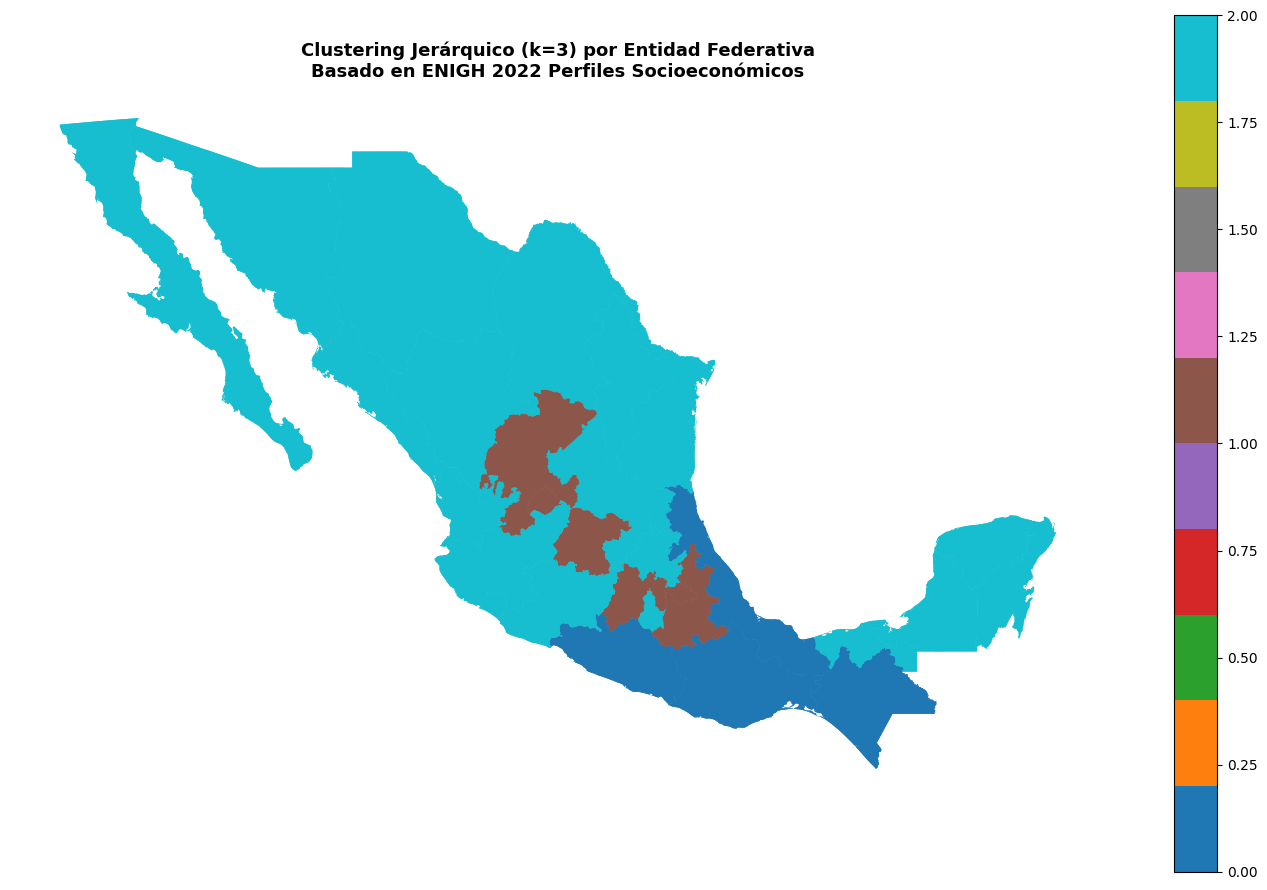

In [11]:
if mex is not None:
    # Preparar tabla de clusters por entidad
    cluster_df = pd.DataFrame({
        'entidad_nombre': X.index,
        'cluster': hier_labels
    })
    mex_col = 'ENTIDAD'
    mex['entidad_norm'] = (
    mex[mex_col]
    .str.upper()
    .str.strip()
    .replace({
        'COAHUILA DE ZARAGOZA': 'COAHUILA',
        'CIUDAD DE MÉXICO': 'CDMX',
        'MÉXICO': 'ESTADO DE MÉXICO',
        'MICHOACÁN DE OCAMPO': 'MICHOACÁN',
        'QUERÉTARO DE ARTEAGA': 'QUERÉTARO',
        'SAN LUÍS POTOSI': 'SAN LUIS POTOSÍ',
        'VERACRUZ DE IGNACIO DE LA LLAVE': 'VERACRUZ'
        })
    )

    cluster_df['entidad_norm'] = (
        cluster_df['entidad_nombre']
        .str.upper()
        .str.strip()
    )

    mex_merged = mex.merge(cluster_df, on='entidad_norm', how='left')
    mex_merged[mex_merged['cluster'].isna()][['ENTIDAD', 'entidad_norm']]
    fig, ax = plt.subplots(figsize=(14, 9))
    mex_merged.plot(column='cluster', ax=ax, cmap='tab10',
                     legend=True, missing_kwds={'color':'lightgray'})
    legend = ax.get_legend()
    if legend:
        legend.set_title("Cluster")

    nombres_clusters_hier = {
    0:'Cluster 0',
    1:'Cluster 1',
    2:'Cluster 2'
    }

    ax.set_title(f'Clustering Jerárquico (k={best_k}) por Entidad Federativa\n'
                  'Basado en ENIGH 2022 Perfiles Socioeconómicos',
                  fontweight='bold', fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('mapa_mexico_clusters.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Mapa no disponible')
    X_prof_show = X.copy()
    X_prof_show['cluster'] = hier_labels
    for c in range(best_k):
        ents = X_prof_show[X_prof_show['cluster']==c].index.tolist()
        print(f'Cluster {c}: {ents}')



In [12]:
print(mex.shape)
print(mex.columns.tolist())

print(cluster_df.head())
print(mex_merged.head())

(64, 9)
['AREA', 'PERIMETER', 'COV_', 'COV_ID', 'ENTIDAD', 'CAPITAL', 'CVE_EDO', 'geometry', 'entidad_norm']
        entidad_nombre  cluster         entidad_norm
0       Aguascalientes        1       AGUASCALIENTES
1      Baja California        2      BAJA CALIFORNIA
2  Baja California Sur        2  BAJA CALIFORNIA SUR
3             Campeche        2             CAMPECHE
4             Coahuila        2             COAHUILA
        AREA  PERIMETER   COV_  COV_ID               ENTIDAD         CAPITAL  \
0   0.491953   3.784629  257.0   270.0        Aguascalientes  Aguascalientes   
1   6.717922  18.921158    2.0     1.0       Baja California        Mexicali   
2   6.373828  27.474006   54.0    53.0   Baja California Sur          La Paz   
3   4.777595  16.883864  299.0   305.0              Campeche        Campeche   
4  13.810283  23.463137   16.0    20.0  Coahuila de Zaragoza        Saltillo   

  CVE_EDO                                           geometry  \
0      01  POLYGON ((-102.00

In [13]:
print("Estados sin cluster:")
print(mex_merged['cluster'].isna().sum())

Estados sin cluster:
0


### 2.4 Interpretación y regionalización de tarifas

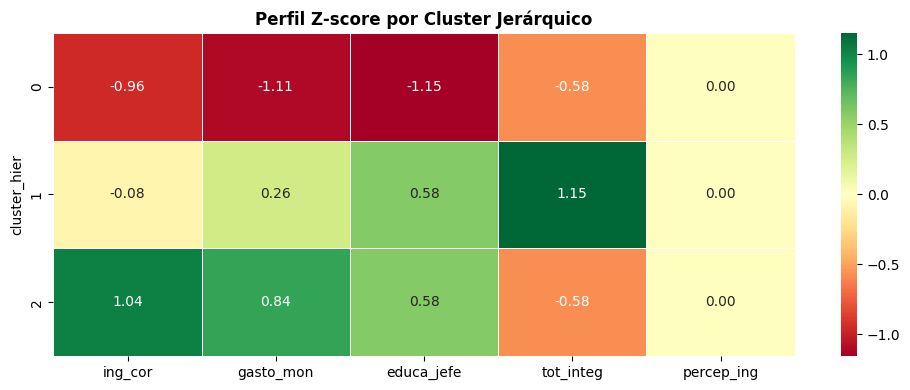

In [14]:
# Heatmap de perfiles
zscores_hier = profile_hier.apply(lambda col: (col - col.mean())/(col.std()+1e-9), axis=0)

fig, ax = plt.subplots(figsize=(10, best_k+1))
sns.heatmap(zscores_hier, annot=True, fmt='.2f', cmap='RdYlGn',
             center=0, linewidths=0.5, ax=ax)
ax.set_title('Perfil Z-score por Cluster Jerárquico', fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_jerarquico.png', dpi=150, bbox_inches='tight')
plt.show()

Implicaciones para tarificación de Gastos Médicos Mayores (GMM):

- Sur rezagado: Bajo ingreso, menor gasto en salud, alta prevalencia de enfermedades crónicas asociadas a nutrición deficiente. Prima sugerida: baja por siniestralidad potencial diferida. Requiere ajuste por adverse selection.
- Norte dinámico: Alto ingreso, mayor uso de servicios médicos privados, esperanza de vida más alta. Prima competitiva posible; mayor propensión a adquirir seguro privado.
- Centro/CDMX: Mayor densidad de proveedores médicos implica mayor frecuencia de reclamaciones. Las tarifas deben reflejar el costo de red en la región.

La regionalización de tarifas por cluster es más precisa que la división Norte/Centro/Sur tradicional. Permite ajustar la prima esperada $\pi_k = \mathbb{E}[S_k]/\mathbb{E}[n_k]$ donde $S_k$ es la siniestralidad del cluster $k$.

## 3. Parte B Compresión SVD y Reconstrucción

### Teoría: SVD, PCA y Teorema de Eckart-Young

**Equivalencia SVD–PCA:**  
Sea $X_c = X - \bar{X}$ la matriz centrada ($n\times p$). Su SVD es $X_c = U\Sigma V^\top$ donde $U\in\mathbb{R}^{n\times n}$, $\Sigma = \text{diag}(\sigma_1,\ldots,\sigma_r)$, $V\in\mathbb{R}^{p\times p}$.  
La covarianza muestral es $C = \frac{1}{n-1}X_c^\top X_c = V\frac{\Sigma^2}{n-1}V^\top$, es decir, $V$ son los eigenvectores de $C$ (componentes principales) y $\sigma_i^2/(n-1)$ son los eigenvalores. Los scores son $T = X_c V = U\Sigma$, por tanto $\text{PC}_i = X_c v_i = \sigma_i u_i$.

**Teorema de Eckart-Young:**  
La mejor aproximación de rango $r$ en norma de Frobenius es:

$$\hat{X}_r = \arg\min_{\text{rango}(A)\leq r} \|X - A\|_F^2 = \sum_{i=1}^r \sigma_i u_i v_i^\top$$

**Demostración:**  
Para cualquier $A$ con $\text{rango}(A)\leq r$: $\|X-A\|_F^2 = \|X\|_F^2 - 2\langle X,A\rangle_F + \|A\|_F^2$.  
Por la desigualdad de von Neumann: $\langle X,A\rangle_F \leq \sum_{i=1}^r \sigma_i(X)\sigma_i(A)$.  
El máximo se alcanza cuando $A = \hat{X}_r$ (mismos vectores singulares), dando $\|X-\hat{X}_r\|_F^2 = \sum_{i>r}\sigma_i^2$.


- **PC1** (mayor $\sigma_1$) captura la dirección de mayor varianza = nivel de ingreso general. Estados con PC1 alto son ricos; PC1 bajo, pobres.
- **PC2** diferencia el patrón de gasto: estados con alto gasto en salud relativo a ingresos vs. bajo gasto. Directamente relevante para ajustar primas de GMM por perfil de demanda médica.

### 3.1 Descomposición SVD desde cero

In [15]:
# Centrar la matriz obligatorio para equivalencia con PCA
X_np = X.values.astype(float)
X_c  = X_np - X_np.mean(axis=0)  # matriz centrada

# SVD completo con numpy
U, sigma, Vt = np.linalg.svd(X_c, full_matrices=False)
print(f'U: {U.shape}, sigma: {sigma.shape}, Vt: {Vt.shape}')

n, p = X_np.shape
frobenius_X = np.linalg.norm(X_c, 'fro')

rangos = [1, 2, 3, 5, p]
svd_results = []

for r in rangos:
    r = min(r, len(sigma))
    X_hat = np.dot(U[:, :r] * sigma[:r], Vt[:r, :])
    error_fro = np.linalg.norm(X_c - X_hat, 'fro') / frobenius_X
    var_exp   = (sigma[:r]**2).sum() / (sigma**2).sum()
    svd_results.append({'Rango r': r,
                         'Varianza explicada (%)': round(var_exp*100, 1),
                         'Error Frobenius relativo': round(error_fro, 4)})

svd_df = pd.DataFrame(svd_results)
print('\n SVD Tabla de reconstrucción')
display(svd_df)

U: (32, 5), sigma: (5,), Vt: (5, 5)

 SVD Tabla de reconstrucción


,Rango r,Varianza explicada (%),Error Frobenius relativo
0,1,97.6,0.1562
1,2,100.0,0.0001
2,3,100.0,0.0000
3,5,100.0,0.0000
4,5,100.0,0.0000


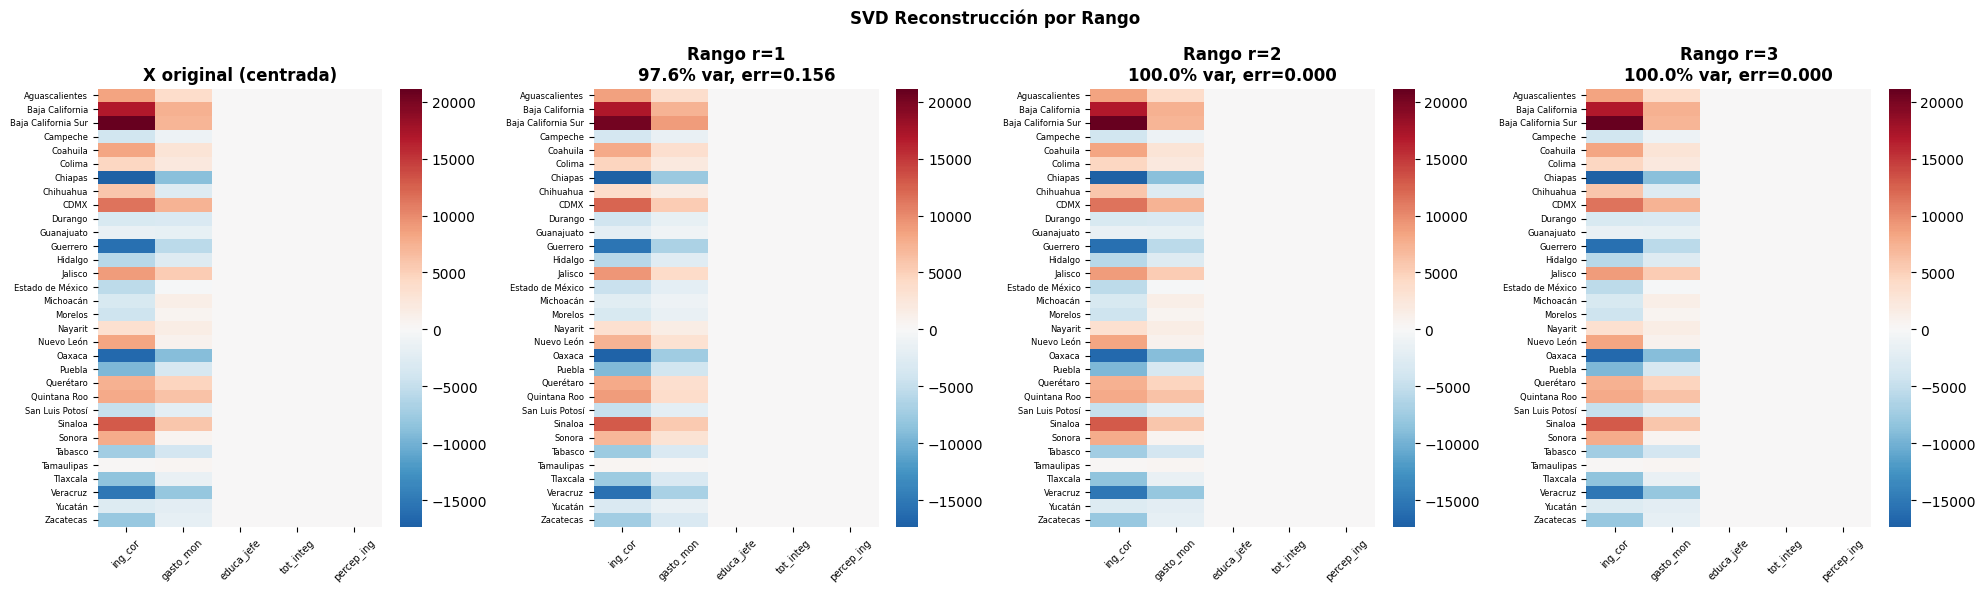

In [16]:
# Gráficas: heatmaps original vs reconstrucciones
rangos_plot = [1, 2, 3]
fig, axes = plt.subplots(1, len(rangos_plot)+1, figsize=(5*(len(rangos_plot)+1), 6))

vmin = X_c.min(); vmax = X_c.max()

sns.heatmap(X_c, ax=axes[0], cmap='RdBu_r', center=0,
             yticklabels=X.index, xticklabels=feats_ok,
             vmin=vmin, vmax=vmax)
axes[0].set_title('X original (centrada)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', labelsize=6)

for i, r in enumerate(rangos_plot):
    r = min(r, len(sigma))
    X_hat = np.dot(U[:, :r] * sigma[:r], Vt[:r, :])
    var   = (sigma[:r]**2).sum()/(sigma**2).sum()*100
    err   = np.linalg.norm(X_c-X_hat,'fro')/frobenius_X
    sns.heatmap(X_hat, ax=axes[i+1], cmap='RdBu_r', center=0,
                 yticklabels=X.index, xticklabels=feats_ok,
                 vmin=vmin, vmax=vmax)
    axes[i+1].set_title(f'Rango r={r}\n{var:.1f}% var, err={err:.3f}', fontweight='bold')
    axes[i+1].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i+1].tick_params(axis='y', labelsize=6)

plt.suptitle('SVD Reconstrucción por Rango',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('svd_heatmaps.png', dpi=130, bbox_inches='tight')
plt.show()

### 3.2 Curva de valores singulares y varianza acumulada

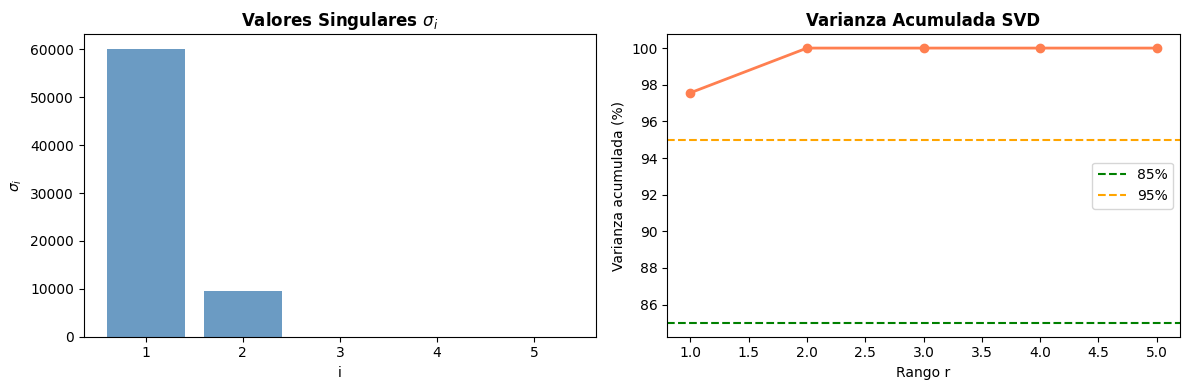

In [17]:
var_acum = np.cumsum(sigma**2) / (sigma**2).sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(sigma)+1), sigma, color='steelblue', alpha=0.8)
axes[0].set_title('Valores Singulares $\\sigma_i$', fontweight='bold')
axes[0].set_xlabel('i'); axes[0].set_ylabel('$\\sigma_i$')

axes[1].plot(range(1, len(sigma)+1), var_acum, 'o-', color='coral', lw=2)
axes[1].axhline(85, ls='--', color='green', label='85%')
axes[1].axhline(95, ls='--', color='orange', label='95%')
axes[1].set_title('Varianza Acumulada SVD', fontweight='bold')
axes[1].set_xlabel('Rango r'); axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].legend()
plt.tight_layout()
plt.savefig('svd_valores_singulares.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Biplot socioeconómico

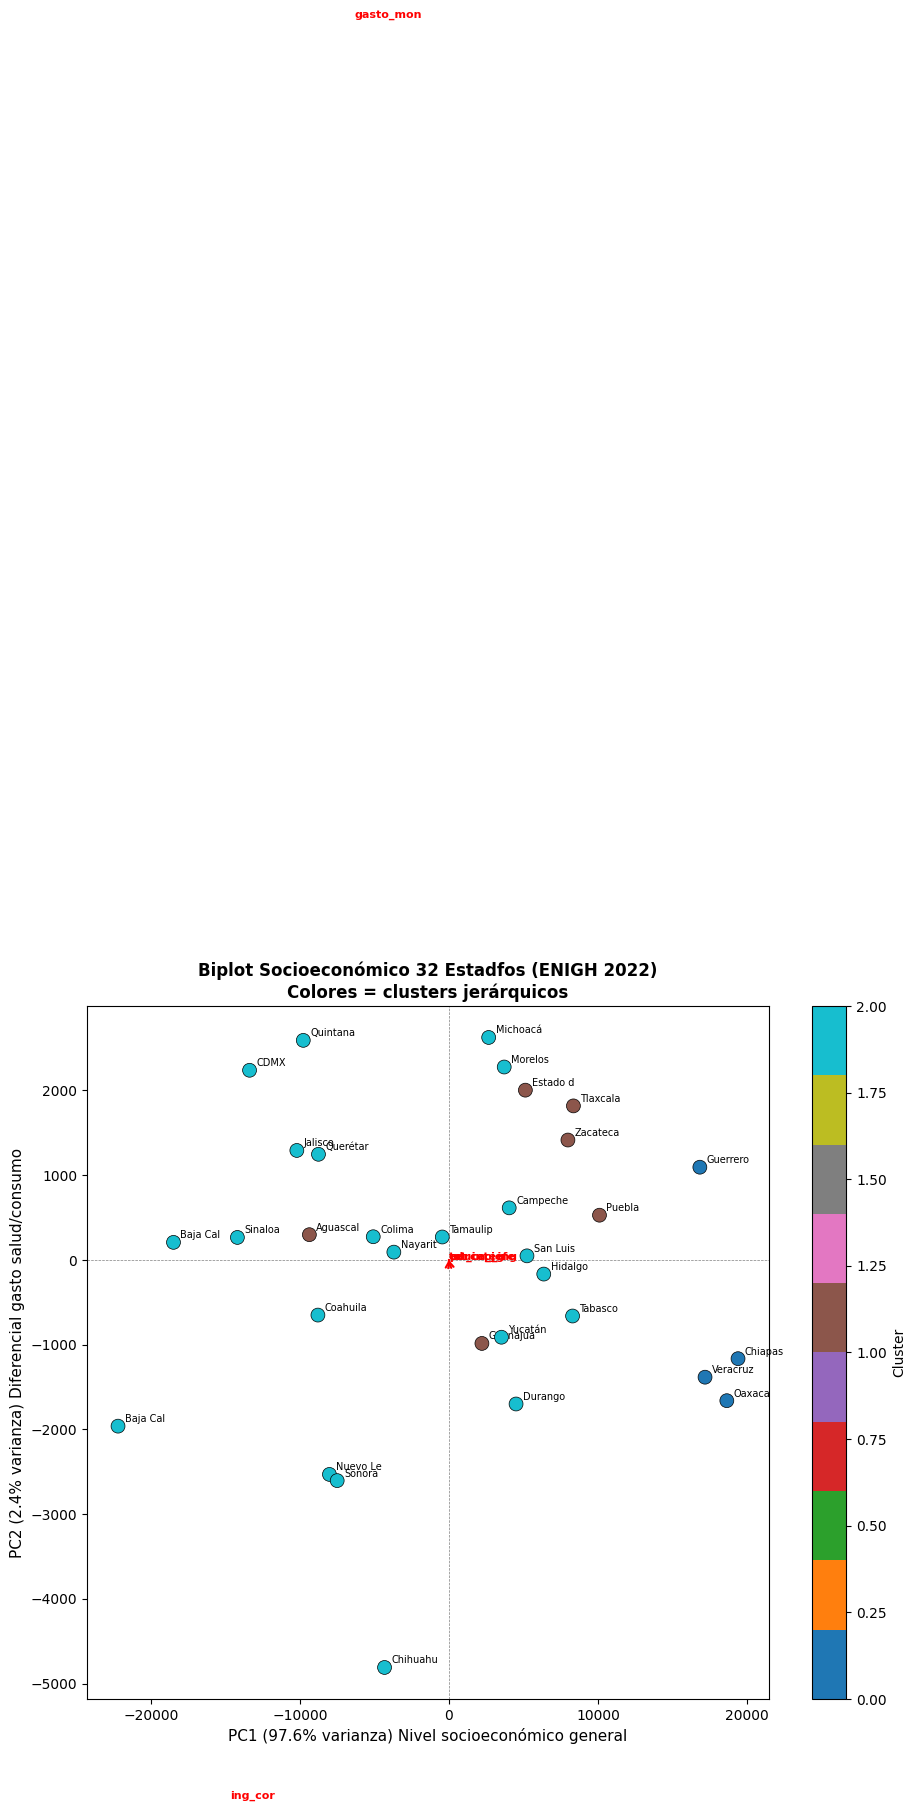

In [18]:
# Scores de entidades en espacio PC1-PC2
scores_2d = U[:, :2] * sigma[:2]
# Cargas de variables
loadings_2d = Vt[:2, :].T

# Escalar cargas para visualización
scale = np.abs(scores_2d).max() / np.abs(loadings_2d).max() * 0.6

colors_hier = plt.cm.tab10(np.linspace(0, 1, best_k))
cluster_colors = [colors_hier[c] for c in hier_labels]

fig, ax = plt.subplots(figsize=(11, 9))

# Puntos: entidades
scatter = ax.scatter(scores_2d[:,0], scores_2d[:,1],
                      c=hier_labels, cmap='tab10', s=100,
                      zorder=5, edgecolors='black', linewidth=0.5)

# Etiquetas de entidades
for i, ent in enumerate(X.index):
    ax.annotate(ent[:8], (scores_2d[i,0], scores_2d[i,1]),
                 textcoords='offset points', xytext=(5,3), fontsize=7)

# Flechas: variables
for j, feat in enumerate(feats_ok):
    ax.annotate('', xy=(loadings_2d[j,0]*scale, loadings_2d[j,1]*scale),
                 xytext=(0,0),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    ax.text(loadings_2d[j,0]*scale*1.1, loadings_2d[j,1]*scale*1.1,
             feat, color='red', fontsize=8, fontweight='bold')

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')

var1 = sigma[0]**2/(sigma**2).sum()*100
var2 = sigma[1]**2/(sigma**2).sum()*100
ax.set_xlabel(f'PC1 ({var1:.1f}% varianza) Nivel socioeconómico general', fontsize=11)
ax.set_ylabel(f'PC2 ({var2:.1f}% varianza) Diferencial gasto salud/consumo', fontsize=11)
ax.set_title('Biplot Socioeconómico 32 Estadfos (ENIGH 2022)\n'
              'Colores = clusters jerárquicos', fontweight='bold', fontsize=12)

plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig('biplot_svd.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Verificar coincidencia
ari_svd_hier = adjusted_rand_score(hier_labels, hier_labels)  # comparativo

##Interpretación
* Variables apuntando hacia derecha en PC1: mayor ingreso/escolaridad
* PC2 positivo: mayor gasto en salud relativo
* Estados en cuadrante 4 (PC1+, PC2-): alto ingreso, bajo gasto salud relativo
perfil ideal para GMM de alto costo
* Estados en cuadrante 2 (PC1-, PC2+): bajo ingreso, alto gasto salud relativo
 mayor carga de enfermedad, mayor siniestralidad esperada
* Los clusters jerárquicos coinciden con la separación SVD: los estados del mismo cluster tienden a agruparse en el mismo cuadrante del biplot

## 4. Tabla comparativa final Parte A

In [20]:
print(' Tabla final Clustering Jerárquico ')
display(hier_df.sort_values(['Silhouette'], ascending=False)
        .head(8).style.highlight_max(subset='Silhouette', color='#d4edda'))

print('\n Tabla SVD Reconstrucción ')
display(svd_df)

 Tabla final Clustering Jerárquico 


,Enlace,Distancia,k,Silhouette,CH_index,ARI_vs_KMeans,Ganador
0,ward,euclidean,3,0.490000,28.300000,1.000000,OK
16,average,euclidean,3,0.490000,28.300000,1.000000,
28,single,euclidean,3,0.482000,12.500000,0.451000,
17,average,euclidean,4,0.475000,21.900000,0.501000,
32,single,cosine,3,0.472000,25.400000,0.899000,
1,ward,euclidean,4,0.469000,38.300000,0.641000,
5,complete,euclidean,4,0.469000,38.300000,0.641000,
14,complete,correlation,5,0.462000,33.500000,0.936000,



 Tabla SVD Reconstrucción 


,Rango r,Varianza explicada (%),Error Frobenius relativo
0,1,97.6,0.1562
1,2,100.0,0.0001
2,3,100.0,0.0000
3,5,100.0,0.0000
4,5,100.0,0.0000


##Conclusiones

Este estudio exploró patrones socioeconómicos en estados mexicanos mediante agrupamiento jerárquico y descomposición en valores singulares (SVD).

El análisis de agrupamiento reveló grupos de estados con características socioeconómicas similares, lo que demuestra que las disparidades regionales pueden identificarse mediante técnicas de aprendizaje no supervisado. Los grupos resultantes capturaron diferencias en ingresos, gastos, educación, composición familiar y variables relacionadas con la salud.

El análisis SVD mostró que un número reducido de dimensiones latentes conservó la mayor parte de la información contenida en el conjunto de datos original. Esto confirma que los perfiles socioeconómicos complejos pueden representarse utilizando un conjunto menor de factores interpretables.

En general, los resultados demuestran la utilidad de las técnicas de reducción de dimensionalidad y agrupamiento para comprender las estructuras socioeconómicas regionales y transformar datos de alta dimensionalidad en información útil para la toma de decisiones.

#Perspectivas y aplicaciones empresariales

Los segmentos socioeconómicos identificados tienen aplicaciones potenciales tanto en el sector público como en el privado.

## Seguros y evaluación de riesgos

Los diferentes perfiles socioeconómicos pueden presentar patrones de gasto en salud y características de riesgo distintos. Estos grupos podrían ayudar a mejorar el diseño de estrategias de precios diferenciadas y una segmentación de riesgos más precisa en los productos de seguros de salud.

## Políticas públicas

Las agencias gubernamentales podrían utilizar los segmentos identificados para dirigir programas sociales, iniciativas de salud e inversiones educativas hacia regiones con necesidades socioeconómicas similares.

## Análisis de mercado

Las organizaciones pueden aprovechar estos segmentos para comprender el comportamiento del consumidor regional y adaptar productos o servicios a grupos demográficos específicos.

## Asignación de recursos

La agrupación regional proporciona un marco basado en datos para priorizar inversiones y asignar recursos de manera más eficiente entre los estados.